In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

df = pd.read_csv('/Users/vicram/Downloads/student-por.csv')

print(df.head())
print(df.shape)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]
(649, 33)


In [3]:
df['Performance'] = (df['G3'] >= 10).astype(int)

print(df[['G3', 'Performance']].head(10))

   G3  Performance
0  11            1
1  11            1
2  12            1
3  14            1
4  13            1
5  13            1
6  13            1
7  13            1
8  17            1
9  13            1


In [5]:
print("Performance Distribution:")
print(df['Performance'].value_counts())

print("\n0 = Fail")
print("1 = Pass")

Performance Distribution:
Performance
1    549
0    100
Name: count, dtype: int64

0 = Fail
1 = Pass


In [7]:
features = [
    'school',
    'sex',
    'age',
    'address',
    'famsize',
    'Pstatus',
    'Medu',
    'Fedu',
    'Mjob',
    'Fjob',
    'reason',
    'guardian',
    'traveltime',
    'studytime',
    'failures',
    'schoolsup',
    'famsup',
    'paid',
    'activities',
    'nursery',
    'higher',
    'internet',
    'romantic',
    'famrel',
    'freetime',
    'goout',
    'Dalc',
    'Walc',
    'health',
    'absences',
    'G1',
    'G2'
]

X = df[features]
y = df['Performance']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  romantic famrel  freetime  goout  Dalc Walc health absences  G1  G2  
0       no      4         3      4     1    1      3        4   0  11  
1       no      5         3      3     1    1      3        2   9  11  
2       no      4         3      2     2    3      3        6  12  13  
3      yes      3         2      2     1    1      5        0  14  14  
4       no      4         3      2     1    2      5        0  11  13  

[5 rows x 32 columns]

Target:
0    1
1    1
2    1
3    1
4    1
Name

In [9]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print("Features after encoding:")
print(X.head())

print("\nNumber of features:", X.shape[1])

Features after encoding:
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         0       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  famsup_yes  \
0     1  ...             True           False           True       False   
1     1  ...            False           False          False        True   
2     2  ...             True           False           True       False   
3     1  ...             True           False          False        True   
4     1  ...            False           False          False        True   

   paid_yes  activities_yes  nursery_

In [11]:
print("Missing Values:")
print(X.isnull().sum().sum())

Missing Values:
0


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (519, 41)
Testing Data: (130, 41)


In [15]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Random Forest Model Training Completed")

Random Forest Model Training Completed


In [17]:
y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
[1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0
 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1]

Predicted Values:
[1 1 1 1 0 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1
 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1]


In [19]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 89.23 %


In [21]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Fail', 'Pass']
    )
)

              precision    recall  f1-score   support

        Fail       0.67      0.60      0.63        20
        Pass       0.93      0.95      0.94       110

    accuracy                           0.89       130
   macro avg       0.80      0.77      0.78       130
weighted avg       0.89      0.89      0.89       130



In [23]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 12   8]
 [  6 104]]


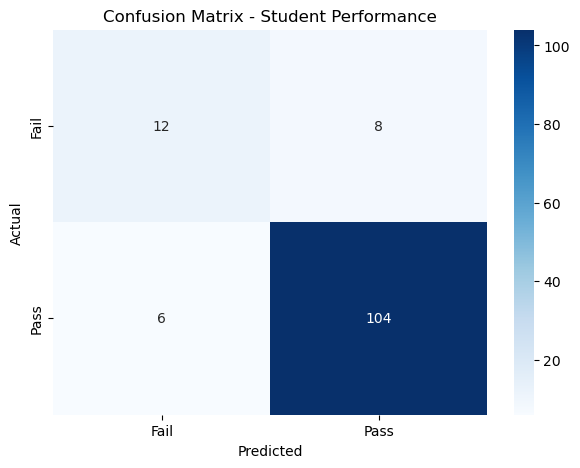

In [25]:
plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fail', 'Pass'],
    yticklabels=['Fail', 'Pass']
)

plt.title('Confusion Matrix - Student Performance')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))

       Feature  Importance
14          G2    0.258603
13          G1    0.198929
5     failures    0.054851
38  higher_yes    0.034299
12    absences    0.032246
15   school_MS    0.031408
6       famrel    0.027621
0          age    0.027336
2         Fedu    0.025561
1         Medu    0.022580
7     freetime    0.022226
10        Walc    0.021997
9         Dalc    0.021471
8        goout    0.021167
11      health    0.020555


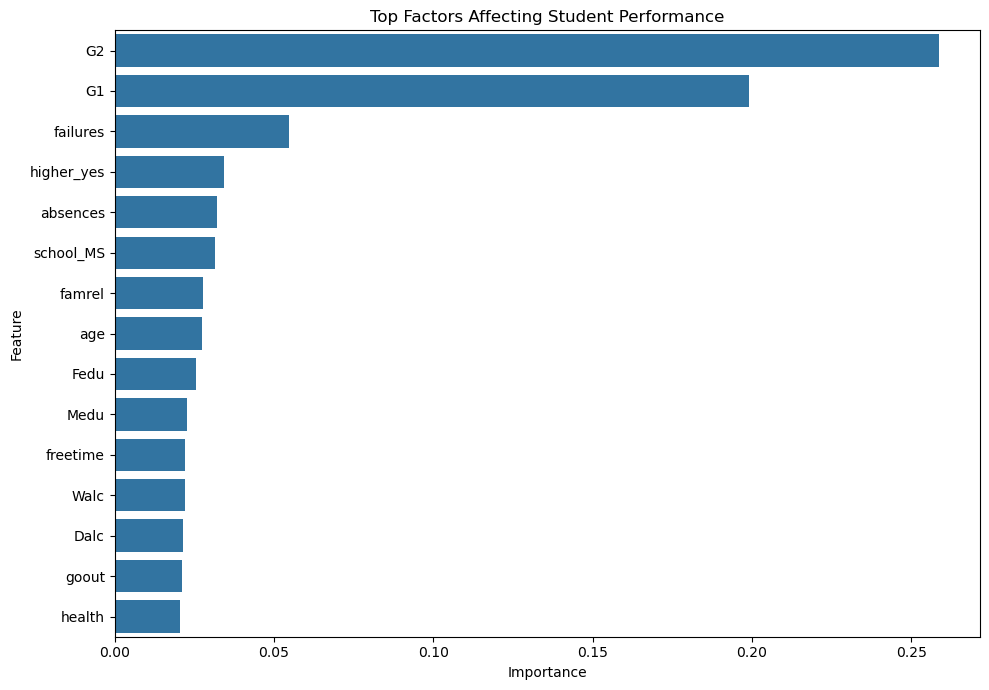

In [29]:
top_features = importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top Factors Affecting Student Performance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [31]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(20))

    Actual  Predicted
0        1          1
1        1          1
2        1          1
3        1          1
4        1          0
5        0          0
6        0          1
7        1          1
8        1          1
9        1          1
10       0          0
11       1          1
12       1          0
13       1          1
14       1          1
15       1          1
16       1          1
17       1          1
18       1          1
19       1          1


0     18
1    112
Name: count, dtype: int64


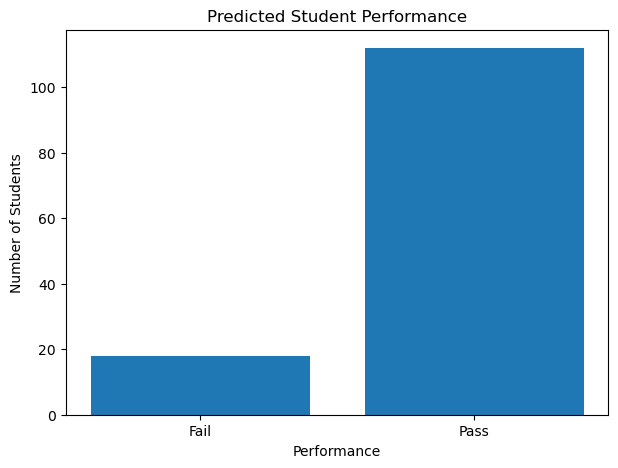

In [33]:
prediction_counts = pd.Series(
    y_pred
).value_counts().sort_index()

print(prediction_counts)

plt.figure(figsize=(7,5))

plt.bar(
    ['Fail', 'Pass'],
    prediction_counts.values
)

plt.title('Predicted Student Performance')
plt.xlabel('Performance')
plt.ylabel('Number of Students')

plt.show()

In [35]:
print("STUDENT PERFORMANCE ANALYSIS")
print("----------------------------")
print("Total Students:", len(df))
print("Training Students:", len(X_train))
print("Testing Students:", len(X_test))
print("Model: Random Forest Classifier")
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Highest G3:", df['G3'].max())
print("Lowest G3:", df['G3'].min())
print("Average G3:", round(df['G3'].mean(), 2))

STUDENT PERFORMANCE ANALYSIS
----------------------------
Total Students: 649
Training Students: 519
Testing Students: 130
Model: Random Forest Classifier
Accuracy: 89.23 %
Highest G3: 19
Lowest G3: 0
Average G3: 11.91


In [37]:
print("CRISP-DM")
print("1. Business Understanding")
print("   Analyze and predict student academic performance.")

print("2. Data Understanding")
print("   Explore student demographic, academic and social information.")

print("3. Data Preparation")
print("   Select relevant features and encode categorical variables.")

print("4. Modeling")
print("   Random Forest Classifier is used for prediction.")

print("5. Evaluation")
print("   Accuracy, classification report and confusion matrix are used.")

print("6. Deployment")
print("   The model can help identify students who may need academic support.")

CRISP-DM
1. Business Understanding
   Analyze and predict student academic performance.
2. Data Understanding
   Explore student demographic, academic and social information.
3. Data Preparation
   Select relevant features and encode categorical variables.
4. Modeling
   Random Forest Classifier is used for prediction.
5. Evaluation
   Accuracy, classification report and confusion matrix are used.
6. Deployment
   The model can help identify students who may need academic support.


In [39]:
print("SEMMA")
print("S - Sample: Select the student performance dataset.")
print("E - Explore: Analyze student academic and demographic data.")
print("M - Modify: Encode categorical variables and prepare features.")
print("M - Model: Apply Random Forest Classification.")
print("A - Assess: Evaluate the model using accuracy and classification metrics.")

SEMMA
S - Sample: Select the student performance dataset.
E - Explore: Analyze student academic and demographic data.
M - Modify: Encode categorical variables and prepare features.
M - Model: Apply Random Forest Classification.
A - Assess: Evaluate the model using accuracy and classification metrics.


In [41]:
print("KDD")
print("1. Selection: Select relevant student attributes.")
print("2. Preprocessing: Clean and prepare the dataset.")
print("3. Transformation: Convert categorical variables into numerical variables.")
print("4. Data Mining: Apply Random Forest Classification.")
print("5. Evaluation: Analyze model predictions and performance.")

KDD
1. Selection: Select relevant student attributes.
2. Preprocessing: Clean and prepare the dataset.
3. Transformation: Convert categorical variables into numerical variables.
4. Data Mining: Apply Random Forest Classification.
5. Evaluation: Analyze model predictions and performance.
